In [1]:
# Random seed for reproducibility
RANDOM_SEED = 7

In [2]:
import pathlib
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import SpectralClustering, KMeans, DBSCAN

from navigoquest.utils.config import standard_dirs, LEVELS, METADATA_COLS, AGE_RANGE
from navigoquest import format_metric_task_data
from navigoquest.utils.pipelines import load_environment, load_paths_normative, load_paths_clinical, pipeline_compute_features
from navigoquest.utils.figures import save_figure

# Load data

In [3]:
# Settings common over levels
output_filenames = {lvl: f"metrics_level{lvl:02}_gb_2480.csv" for lvl in np.arange(1, 99)}
task_list = ['voc', 'path_length', 'average_curvature', 'boundary_affinity',
             'frobenius_deviation', 'supremum_deviation', 'conformity', 'vector_conformity']
metrics_list = ['duration'] + task_list[1:]

# Directories
dirs = standard_dirs()
paths_dir = dirs['paths']
output_dir = dirs['output']
if not output_dir.exists():
    output_dir.mkdir(parents=True)

# Load environment
env_store = load_environment(dirs)

Loading environment data...
done. 



In [4]:
paths_all = {}
envs_all = {}
for lvl in LEVELS:
    # Arguments for the pipeline
    path_data = load_paths_normative(lvl, dirs, AGE_RANGE)
    env_data = env_store.get(lvl)
    
    paths_all[lvl] = path_data
    envs_all[lvl] = env_data

Loading path data...
corrupted data for entry: 68826
corrupted data for entry: 117532
dropping 0 unmatched path(s)
done. 

Loading path data...
corrupted data for entry: 44618
corrupted data for entry: 68024
dropping 0 unmatched path(s)
done. 

Loading path data...
corrupted data for entry: 49304
corrupted data for entry: 49432
dropping 0 unmatched path(s)
done. 

Loading path data...
corrupted data for entry: 33652
corrupted data for entry: 79820
dropping 0 unmatched path(s)
done. 

Loading path data...
corrupted data for entry: 27905
corrupted data for entry: 95579
dropping 0 unmatched path(s)
done. 



In [5]:
# Feature dataframes
output_df_all_loaded = {lvl: pd.read_csv(output_dir / output_filenames[lvl]) for lvl in LEVELS}

### Match paths and df by ordering

In [6]:
argsort_paths_all = {}
argsort_df_all = {}
checkers = []
for lvl in LEVELS:
    paths_id = np.array([item.metadata['instance_id'] for item in paths_all[lvl]])
    df_id = output_df_all_loaded[lvl]['instance_id'].to_numpy()

    paths_id2 = np.array([item.metadata['user_id'] for item in paths_all[lvl]])
    df_id2 = output_df_all_loaded[lvl]['user_id'].to_numpy()

    id_mismatch = np.sort(paths_id) != np.sort(df_id)
    size_mismatch = paths_id.size - df_id.size

    checkers.append(np.sum(id_mismatch) == 0) # ID Mismatch
    checkers.append(size_mismatch == 0) # Size mismatch

    argsort_paths = np.argsort(paths_id)
    argsort_df = np.argsort(df_id)

    argsort_paths_all[lvl] = argsort_paths
    argsort_df_all[lvl] = argsort_df
print(f'Checks passed = {np.sum(checkers)}/{len(checkers)}')

# Reorder paths and df
for lvl in LEVELS:
    paths_all[lvl] = list(np.array(paths_all[lvl])[argsort_paths_all[lvl]])
    output_df_all_loaded[lvl] = output_df_all_loaded[lvl].loc[argsort_df_all[lvl]]

# Second check
checkers = []
# Check that reordered ID's are equal (Instance ID)
for lvl in LEVELS:
    id_paths = np.array([item.metadata['instance_id'] for item in paths_all[lvl]])
    id_df = output_df_all_loaded[lvl]['instance_id'].to_numpy()
    checkers.append(np.all(id_paths == id_df))
# Check that reordered ID's are equal (User ID)
for lvl in LEVELS:
    id_paths = np.array([item.metadata['user_id'] for item in paths_all[lvl]])
    id_df = output_df_all_loaded[lvl]['user_id'].to_numpy()
    checkers.append(np.all(id_paths == id_df))
print(f'Checks passed = {np.sum(checkers)}/{len(checkers)}')

Checks passed = 10/10
Checks passed = 10/10


# Clinical data
### Load and match

In [7]:
# Load clinical data
paths_clinical_all = {}
envs_clinical_all = {}
for lvl in LEVELS:
    # Arguments for the pipeline
    path_data = load_paths_clinical(lvl, dirs)
    env_data = env_store.get(lvl)
    
    paths_clinical_all[lvl] = path_data
    envs_clinical_all[lvl] = env_data

# Load clinical features dataframe
df_clinical_collated = pd.read_csv(output_dir / "clinical_metrics.csv")
# Separate by level
df_clinical = {lvl: df_clinical_collated[df_clinical_collated['level'] == lvl] for lvl in LEVELS}

In [8]:
# Match paths_clinical_all and df_clinical by ordering
match_key = 'duration'
argsort_paths_clinical_all = {}
argsort_df_clinical_all = {}
checkers = []
# Compute argsort
for lvl in LEVELS:
    paths_key = np.array([item.metadata[match_key] for item in paths_clinical_all[lvl]])
    df_key = df_clinical[lvl][match_key].to_numpy()

    id_mismatch = np.sort(paths_key) != np.sort(df_key)
    size_mismatch = paths_key.size - df_key.size

    checkers.append(np.sum(id_mismatch) == 0)
    checkers.append(size_mismatch == 0)

    argsort_paths = np.argsort(paths_key)
    argsort_df = np.argsort(df_key)

    argsort_paths_clinical_all[lvl] = argsort_paths
    argsort_df_clinical_all[lvl] = argsort_df
print(f'Checks passed = {np.sum(checkers)}/{len(checkers)}')

# Reorder paths and df
for lvl in LEVELS:
    # paths_clinical_all
    item_paths = np.array(paths_clinical_all[lvl])
    item_paths = item_paths[argsort_paths_clinical_all[lvl]]
    item_paths = list(item_paths)
    paths_clinical_all[lvl] = item_paths

    # df_clinical
    item_df = df_clinical[lvl]
    item_df = item_df.iloc[argsort_df_clinical_all[lvl]]
    item_df = item_df.reset_index(drop=True)
    df_clinical[lvl] = item_df

    # paths_clinical_all[lvl] = list(np.array(paths_clinical_all[lvl])[argsort_paths_clinical_all[lvl]])
    # df_clinical[lvl] = df_clinical[lvl].iloc[argsort_df_clinical_all[lvl]].reset_index(drop=True)

# Verification check
checkers = []
for lvl in LEVELS:
    id_paths = np.array([item.metadata[match_key] for item in paths_clinical_all[lvl]])
    id_df = df_clinical[lvl][match_key].to_numpy()
    checkers.append(np.all(id_paths == id_df))
print(f'Checks passed = {np.sum(checkers)}/{len(checkers)}')

Checks passed = 10/10
Checks passed = 5/5


# Clustering

In [9]:
# Setting
n_clus = 12
n_display = 4
n_display_ad = 4 # Number of paths from AD dataset to display
subgp = 'ad'
seed = RANDOM_SEED

Working on Level 6...
Cluster algo agrees with 18/18 entries of cluster centroid distance argmin
Saved 'clusters_k12_level06': clusters_k12_level06.pdf, clusters_k12_level06.svg, source_data/clusters_k12_level06.xlsx (tabs: clusters_k12_level06)


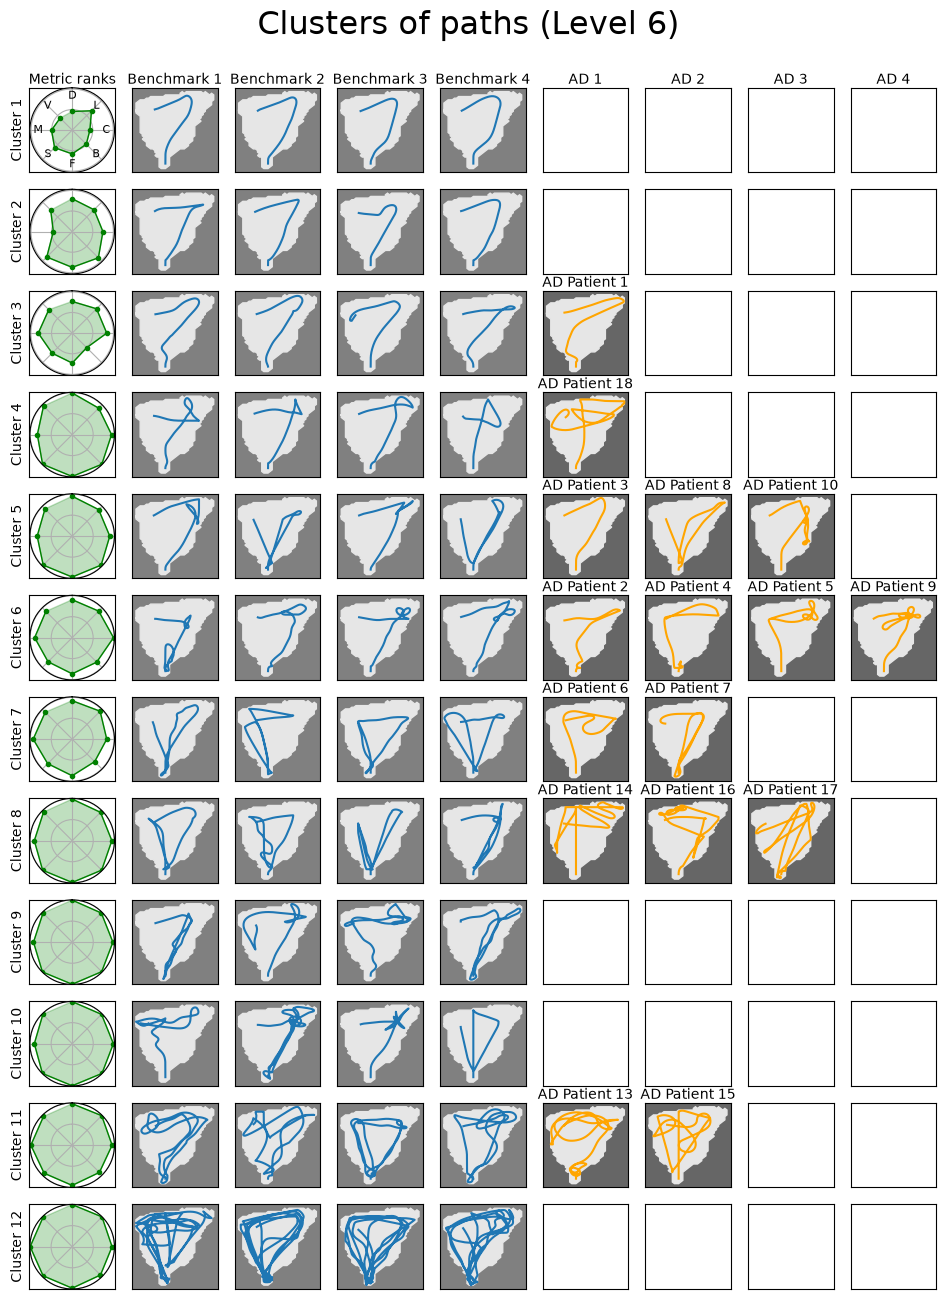

Working on Level 8...
Cluster algo agrees with 15/15 entries of cluster centroid distance argmin
Saved 'clusters_k12_level08': clusters_k12_level08.pdf, clusters_k12_level08.svg, source_data/clusters_k12_level08.xlsx (tabs: clusters_k12_level08)


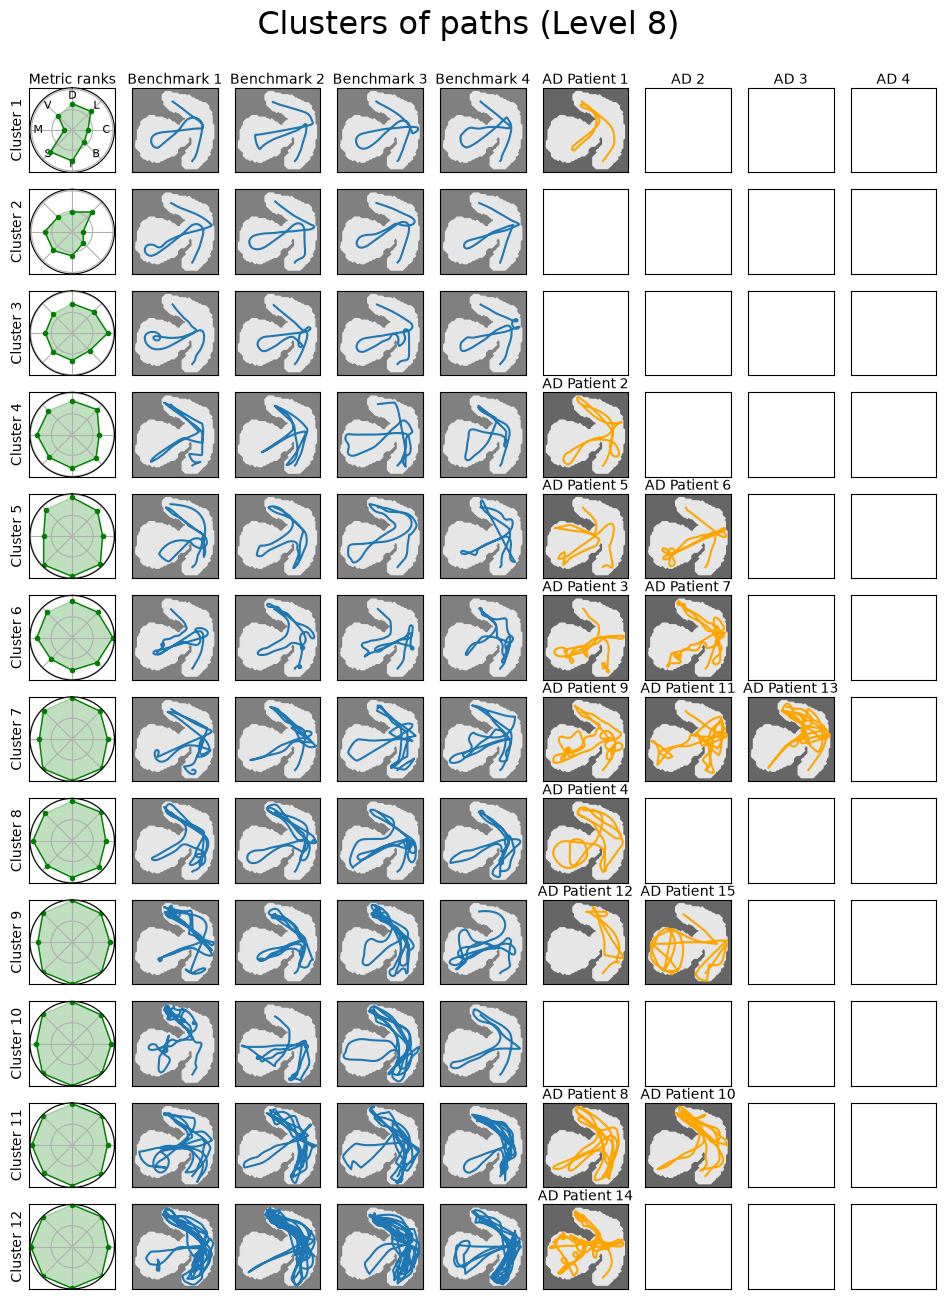

Working on Level 11...
Cluster algo agrees with 11/11 entries of cluster centroid distance argmin
Saved 'clusters_k12_level11': clusters_k12_level11.pdf, clusters_k12_level11.svg, source_data/clusters_k12_level11.xlsx (tabs: clusters_k12_level11)


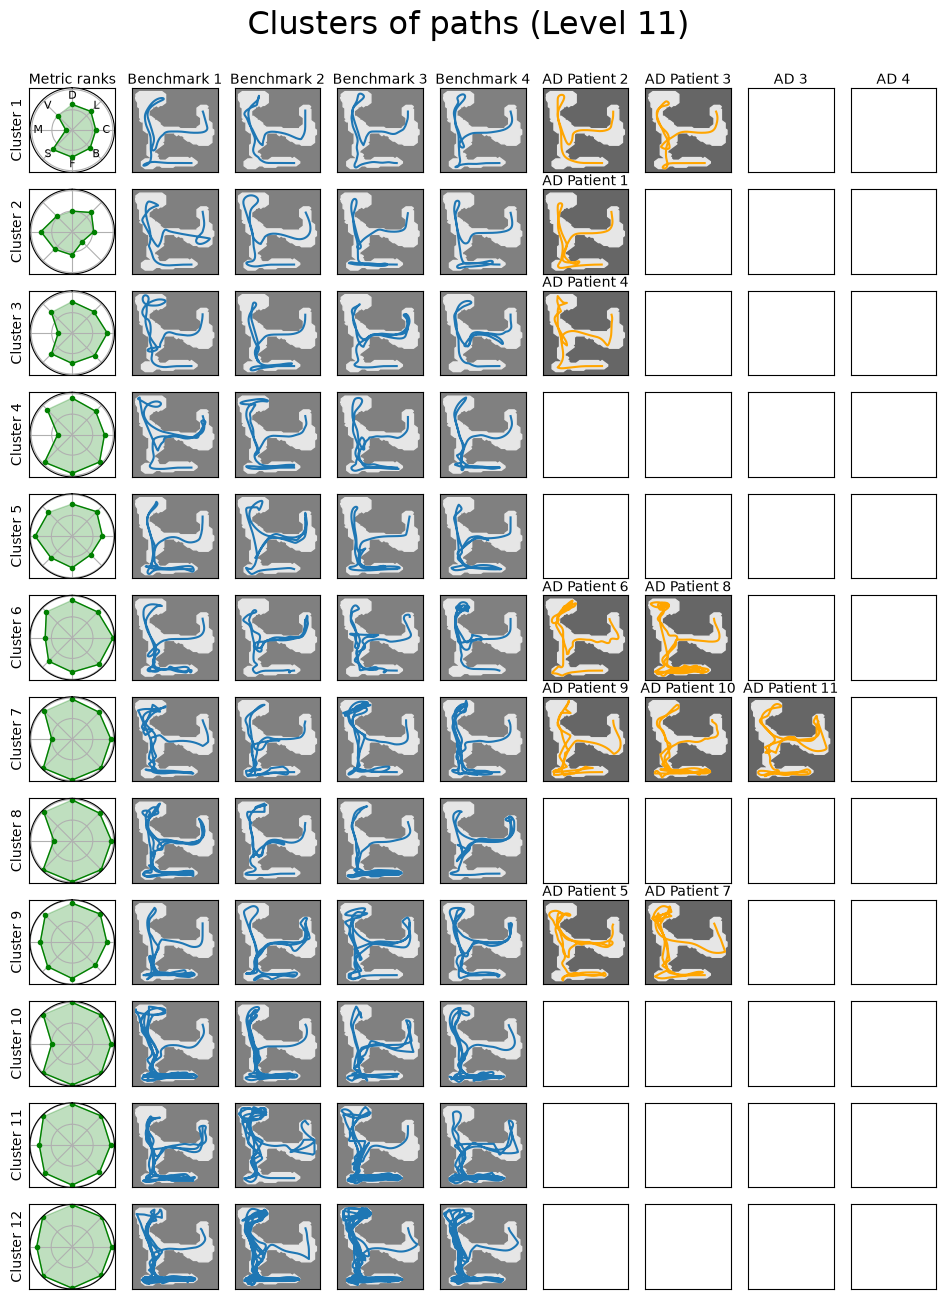

In [10]:
clus_all = {}
X_all = {}

for lvl in [6, 8, 11]:
    print(f'Working on Level {lvl}...')

    # Clustering part (not the plotting part)
    # Dataframe
    df = output_df_all_loaded[lvl]
    df_lengths = df['path_length'].to_numpy()
    df_lengths_rank = np.argsort(np.argsort(df_lengths))
    # Mask for the subset of data to cluster
    mask = df_lengths_rank > int(0.5 * len(df)) # Longest half
    # mask = df_lengths_rank >= int(0.0 * len(df)) # Uncomment to use all paths
    inds_mask = np.nonzero(mask)[0]

    # Define numpy arrays to compute
    X_full = df[metrics_list].to_numpy()
    X = X_full[mask]
    # Normalise to mean, std = 0, 1
    mean_Xfull, std_Xfull = np.mean(X_full, axis=0), np.std(X_full, axis=0)
    X_full = (X_full - mean_Xfull) / std_Xfull
    X = (X - mean_Xfull) / std_Xfull
    X_all[lvl] = X

    # Main clustering step
    clus_clf = KMeans(n_clusters=n_clus, random_state=seed).fit(X)
    clus = clus_clf.predict(X)
    clus_all[lvl] = clus

    # Mean and std of each cluster
    mean_clus = np.zeros((n_clus, len(metrics_list)))
    std_clus = np.zeros((n_clus, len(metrics_list)))
    for idx_clus in range(n_clus):
        item_clus = X[clus == idx_clus]
        mean_clus[idx_clus] = np.mean(item_clus, axis=0)
        std_clus[idx_clus] = np.std(item_clus, axis=0)
    # Sort clusters by length
    argsort_clus_length = np.argsort(mean_clus[:, 1]) # 1 is index of path_length
    rank_clus_length = np.argsort(np.argsort(mean_clus[:, 1])) # Double argsort = rank
    mean_clus = mean_clus[argsort_clus_length]
    std_clus = std_clus[argsort_clus_length]
    clus_updated = np.zeros(clus.shape)
    for idx_clus in range(n_clus):
        clus_updated[clus == idx_clus] = rank_clus_length[idx_clus]
    clus = clus_updated.copy()
    clus_all[lvl] = clus
    del clus_updated
    # Rank of cluster centroids
    meanrank_clus = np.zeros(mean_clus.shape)
    for i in range(len(metrics_list)):
        for j in range(n_clus):
            meanrank_clus[j, i] = np.sum(mean_clus[j, i] > X_full[:, i]) / X_full.shape[0]

    # Part 2: Identify benchmark paths
    inds_display_all = {}
    for idx_clus, item_mean, item_std in zip(range(n_clus), mean_clus, std_clus):
        # Compute centrality (distance from mean)
        item_clus = X[clus == idx_clus]
        inds_clus = np.nonzero(clus == idx_clus)[0]
        item_centrality = np.linalg.norm(item_clus - item_mean, axis=1)
        inds_centrality = np.argsort(item_centrality)

        # Indices to display
        inds_display = inds_centrality[:n_display]
        inds_display = inds_clus[inds_display]
        inds_display = inds_mask[inds_display] # Mask variable in the previous cell
        inds_display_all[idx_clus] = inds_display

    # Part 3: Identify paths from clinical subgroup
    mask = (df_clinical[lvl]['group'] == subgp)
    # Paths we use
    paths_subgroup = [paths_clinical_all[lvl][idx] for idx in np.nonzero(mask)[0]]
    Y0 = df_clinical[lvl][mask][metrics_list].to_numpy()
    Y = (Y0 - mean_Xfull) / std_Xfull
    X0 = df[metrics_list].to_numpy()

    # Apply clustering trained above on X
    Y_clus0 = clus_clf.predict(Y)
    Y_clus = np.zeros(Y_clus0.shape)
    # Clusters were reordered based on path lengths
    for idx_clus in range(n_clus):
        Y_clus[Y_clus0 == idx_clus] = rank_clus_length[idx_clus]
    # Check that prediction agrees with a simple argmin comparison against centroids (mean_clus).
    centroid_checker = np.array([np.argmin(np.linalg.norm(mean_clus - Y[i], axis=1)) for i in range(Y.shape[0])])
    print(f'Cluster algo agrees with {np.sum(centroid_checker == Y_clus)}/{Y_clus.size} entries of cluster centroid distance argmin')

    # Part 4: Plotting
    n_cols = n_display+1+n_display_ad
    fig, ax = plt.subplots(nrows=n_clus, ncols=n_cols)
    fig.set_size_inches(1.3*(n_cols), 1.3*n_clus)
    plt.suptitle(f'Clusters of paths (Level {lvl})', fontsize=23, y=0.93)
    # plt.subplots_adjust(wspace=0.3)
    # Boundary of the environment
    bdy = np.load(dirs['env_boundary'] / f"level{lvl:02}_inner_bdry.npy")
    # Radar
    for idx_clus in range(n_clus):
        ax_now = ax[idx_clus, 0]
        angles = np.linspace(0, 2*np.pi, 8, endpoint=False).tolist()
        values = meanrank_clus[idx_clus]
        ax_now = plt.subplot(n_clus, n_cols, 1 + idx_clus * n_cols, 
                projection='polar', theta_direction=-1, theta_offset = np.pi/2)
        ax_now.scatter([0], [1], c='red', alpha=0)
        ax_now.plot(angles, values, 'o-', linewidth=1, markersize=3, color='green')
        ax_now.fill(angles, values, alpha=0.25, c='green')
        if idx_clus == 0:
            ax_now.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
            ax_now.set_xticklabels(['D', 'L', 'C', 'B', 'F', 'S', 'M', 'V'], y=0.65, fontsize=8)
        else:
            ax_now.set_xticklabels([])
        ax_now.set_yticklabels([])
        ax_now.set_ylabel(f'Cluster {idx_clus+1}')

    # Show labels of columns
    ax[0, 0].set_title('Metric ranks', fontsize=10, y=0.95)
    for j in range(n_display):
        ax[0, j+1].set_title(f'Benchmark {j+1}', fontsize=10, y=0.95)
    for j in range(n_display_ad):
        ax[0, j+1+n_display].set_title(f'AD {j+1}', fontsize=10, y=0.95)

    # Display paths from benchmark dataset
    for idx_clus in range(n_clus):
        for j in range(inds_display_all[idx_clus].size):
            idx_disp = inds_display_all[idx_clus][j]
            ax[idx_clus, j+1].plot(paths_all[lvl][idx_disp].smooth_xy.T[0], paths_all[lvl][idx_disp].smooth_xy.T[1])
        for j in range(n_cols):
            ax[idx_clus, j].set_xticks([])
            ax[idx_clus, j].set_yticks([])

    # Display paths from AD dataset, with matching clusters
    ad_path_counter = [0 for _ in range(n_clus)]
    for i in range(len(paths_subgroup)):
        idx_clus = int(Y_clus[i])
        idx_display = ad_path_counter[idx_clus] + 1 + n_display
        item_path = paths_subgroup[i].smooth_xy
        # vel_path = np.linalg.norm(np.diff(item_path, axis=0), axis=1)
        # vel_path = np.concatenate(([0], vel_path)) # Add 0 velocity for the first point to match path length

        if idx_display < n_cols:
            ax[idx_clus, idx_display].plot(item_path.T[0], item_path.T[1], c='orange')
            ax[idx_clus, idx_display].set_title(f'AD Patient {i+1}', fontsize=10, y=0.95)
            ax[idx_clus, idx_display].set_xticks([])
            ax[idx_clus, idx_display].set_yticks([])

            # Color the background
            color1 = (0.4, 0.4, 0.4, 1) # Background
            color2 = (0.9, 0.9, 0.9, 1) # Inner area
            ax_now = ax[idx_clus, idx_display]
            ax_now.set_facecolor(color = color1)
            ax_now.fill(bdy.T[0], bdy.T[1], color = color2, zorder = 0)

        # Add to counter
        ad_path_counter[idx_clus] += 1

    # Show maps
    for i in range(n_clus):
        for j in range(n_display + 1):
            if j == 0:
                continue
            
            color1 = (0.5, 0.5, 0.5, 1) # Background
            color2 = (0.9, 0.9, 0.9, 1) # Inner area
            ax_now = ax[i, j]
            ax_now.set_facecolor(color = color1)
            ax_now.fill(bdy.T[0], bdy.T[1], color = color2, zorder = 0)

    save_figure(fig, f"clusters_k{n_clus}_level{lvl:02}")
    plt.show()

# Cluster visualisation

In [11]:
# Dimensionality reduction
X_pca = {}
X_tsne= {}
X_umap = {}
for lvl in [6, 8, 11]:
    print(f'Working on Level {lvl}...')
    X_pca[lvl] = PCA(n_components=2).fit_transform(X_all[lvl])
    X_tsne[lvl] = TSNE(n_components=2).fit_transform(X_all[lvl])
    X_umap[lvl] = UMAP(n_components=2).fit_transform(X_all[lvl])

Working on Level 6...
Working on Level 8...
Working on Level 11...


KeyboardInterrupt: 

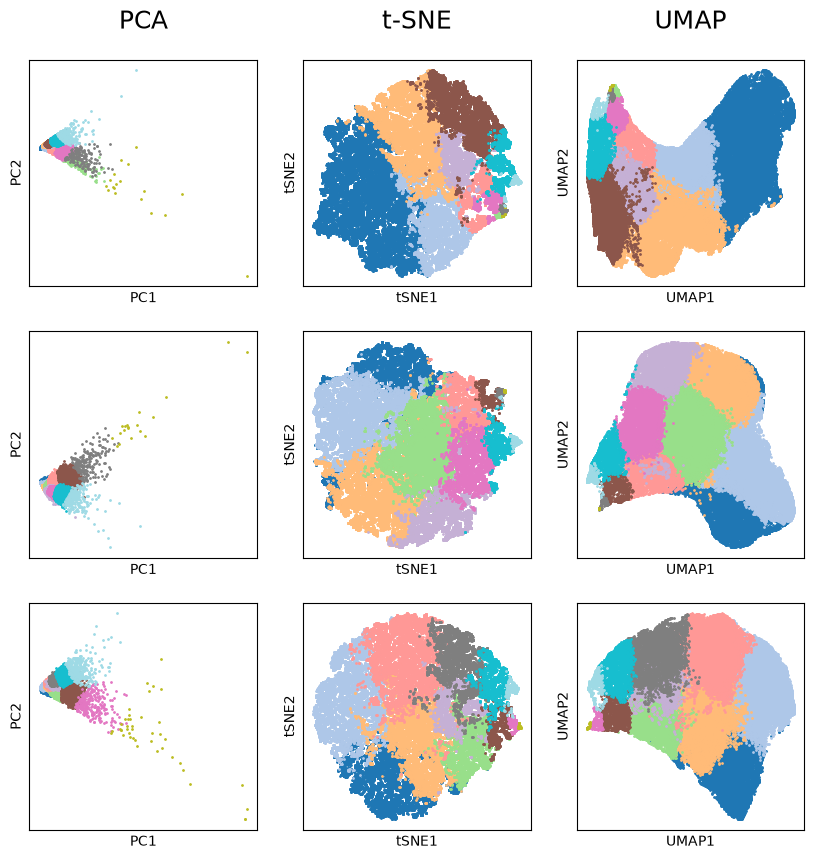

In [ ]:
# cmap = plt.cm.get_cmap('tab20', n_clus)
cmap = plt.colormaps['tab20'].resampled(n_clus)
CLUSTER_COLORS = [cmap(i) for i in range(n_clus)]

fig, ax = plt.subplots(ncols=3, nrows=3)
fig.set_size_inches(10, 10)

for idx_lvl, lvl in enumerate([6, 8, 11]):
    clus_now = clus_all[lvl]

    for i in range(n_clus):
        mask = (clus_now == i)
        ax[idx_lvl,0].scatter(X_pca[lvl][mask][:,0],
                              X_pca[lvl][mask][:,1], s=1, color=CLUSTER_COLORS[i])
        ax[idx_lvl,1].scatter(X_tsne[lvl][mask][:,0],
                              X_tsne[lvl][mask][:,1], s=1, color=CLUSTER_COLORS[i])
        ax[idx_lvl,2].scatter(X_umap[lvl][mask][:,0],
                              X_umap[lvl][mask][:,1], s=1, color=CLUSTER_COLORS[i])

        ax[idx_lvl, 0].set_xlabel(f'PC1')
        ax[idx_lvl, 0].set_ylabel(f'PC2')
        ax[idx_lvl, 1].set_xlabel(f'tSNE1')
        ax[idx_lvl, 1].set_ylabel(f'tSNE2')
        ax[idx_lvl, 2].set_xlabel(f'UMAP1')
        ax[idx_lvl, 2].set_ylabel(f'UMAP2')
        for j in range(3):
            ax[idx_lvl, j].set_xticks([])
            ax[idx_lvl, j].set_yticks([])

ax[0, 0].set_title(f'PCA', fontsize=18, y=1.1)
ax[0, 1].set_title(f't-SNE', fontsize=18, y=1.1)
ax[0, 2].set_title(f'UMAP', fontsize=18, y=1.1)


# Source data: embedding coordinates and cluster of every clustered path
embedding_tables = {
    f"level{lvl:02}": pd.DataFrame({
        "cluster": clus_all[lvl].astype(int) + 1,
        "PC1": X_pca[lvl][:, 0], "PC2": X_pca[lvl][:, 1],
        "tSNE1": X_tsne[lvl][:, 0], "tSNE2": X_tsne[lvl][:, 1],
        "UMAP1": X_umap[lvl][:, 0], "UMAP2": X_umap[lvl][:, 1],
    })
    for lvl in [6, 8, 11]
}
save_figure(fig, "cluster_embeddings", data=embedding_tables, auto=False)
plt.show()

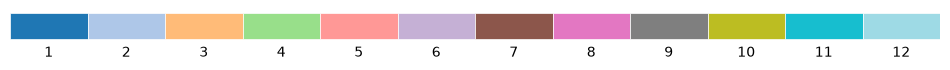

In [ ]:
# Cluster colour index — horizontal bar
fig, ax = plt.subplots(figsize=(n_clus * 0.8, 0.8))

for i in range(n_clus):
    ax.barh(0, 1, left=i, color=CLUSTER_COLORS[i], edgecolor='white', linewidth=0.5)
    ax.text(i + 0.5, -0.6, str(i + 1), ha='center', va='top', fontsize=10)

ax.set_xlim(0, n_clus)
ax.set_ylim(-1, 0.5)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "cluster_colour_key")
plt.show()


# Cluster quality evaluation
### Bootstrap stability

In [ ]:
X_all = {}

for lvl in [6, 8, 11]:
    df = output_df_all_loaded[lvl]
    df_lengths = df['path_length'].to_numpy()
    df_lengths_rank = np.argsort(np.argsort(df_lengths))

    # Mask for the subset of data to cluster
    mask = df_lengths_rank > int(0.5 * len(df)) # Longest half
    inds_mask = np.nonzero(mask)[0]

    # Define numpy arrays to compute
    X_full = df[metrics_list].to_numpy()
    X = X_full[mask]

    # Normalise to mean, std = 0, 1
    mean_Xfull, std_Xfull = np.mean(X_full, axis=0), np.std(X_full, axis=0)
    X_full = (X_full - mean_Xfull) / std_Xfull
    X = (X - mean_Xfull) / std_Xfull

    X_all[lvl] = X

In [ ]:
n_clus_all = list(range(2, 21))

In [ ]:
from scipy.optimize import linear_sum_assignment

n_bootstrap = 100
bootstrap_stability_all = {}  # (lvl, k) -> array of shape (n_bootstrap, k)

for lvl in [6, 8, 11]:
    print(f'Working on Level {lvl}...')
    X = X_all[lvl]
    n = X.shape[0]
    rng = np.random.RandomState(seed)

    for k in n_clus_all:
        # Reference clustering on full data
        ref_clf = KMeans(n_clusters=k, random_state=seed).fit(X)
        ref_labels = ref_clf.predict(X)

        jaccard_per_boot = []
        for b in range(n_bootstrap):
            boot_idx = rng.choice(n, size=n, replace=True)
            boot_clf = KMeans(n_clusters=k, random_state=seed).fit(X[boot_idx])
            boot_labels = boot_clf.predict(X)

            # Build k×k Jaccard matrix between reference and bootstrap clusters
            jaccard_mat = np.zeros((k, k))
            for c_ref in range(k):
                mask_ref = ref_labels == c_ref
                for c_boot in range(k):
                    mask_boot = boot_labels == c_boot
                    intersection = np.sum(mask_ref & mask_boot)
                    union = np.sum(mask_ref | mask_boot)
                    jaccard_mat[c_ref, c_boot] = intersection / union if union > 0 else 0.0

            # Hungarian matching to find best-aligned cluster pairs
            row_ind, col_ind = linear_sum_assignment(-jaccard_mat) # linear_sum_assignment finds minimum assignment, so add the negative sign
            jaccard_per_boot.append(jaccard_mat[row_ind, col_ind])

        bootstrap_stability_all[(lvl, k)] = np.array(jaccard_per_boot)  # (n_bootstrap, k)

    print(f'  Done.')

Working on Level 6...
  Done.
Working on Level 8...
  Done.
Working on Level 11...
  Done.


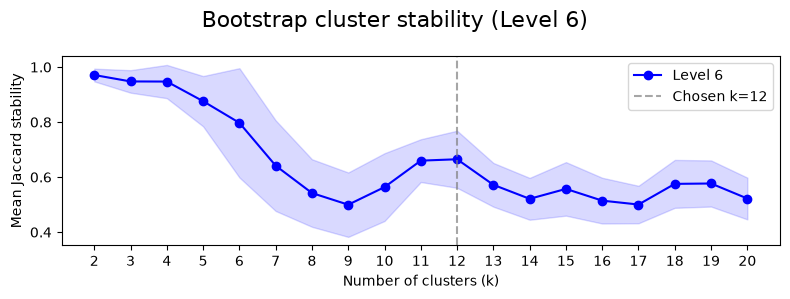

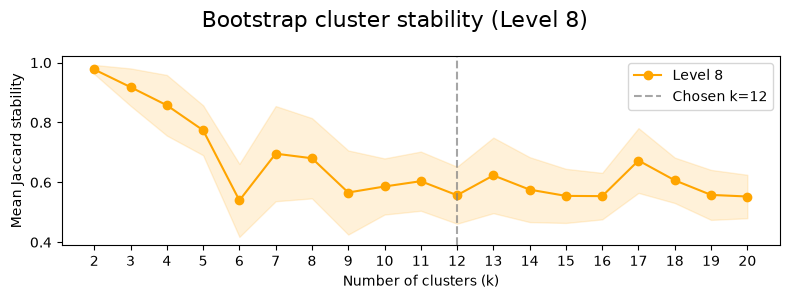

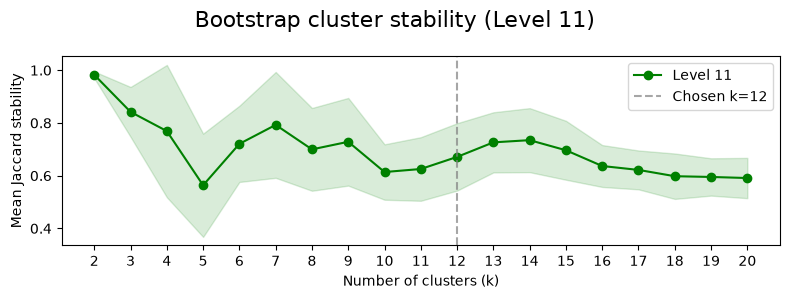

In [ ]:
n_clus = 12
plot_colors = ['blue', 'orange', 'green']

for idx_lvl, lvl in enumerate([6, 8, 11]):
    fig, ax = plt.subplots()
    fig.set_size_inches(8, 3)

    ax_now = ax
    # Mean Jaccard averaged over bootstrap runs and clusters
    mean_stab = np.array([np.mean(bootstrap_stability_all[(lvl, k)]) for k in n_clus_all])
    # Std across bootstrap runs (of the per-run mean Jaccard)
    std_stab = np.array([np.std(np.mean(bootstrap_stability_all[(lvl, k)], axis=1)) for k in n_clus_all])

    line, = ax_now.plot(n_clus_all, mean_stab, 'o-', label=f'Level {lvl}', c=plot_colors[idx_lvl])
    ax_now.fill_between(n_clus_all, mean_stab - std_stab, mean_stab + std_stab,
                    alpha=0.15, color=line.get_color())

    ax_now.set_xticks(n_clus_all)
    ax_now.axvline(x=n_clus, color='gray', linestyle='--', alpha=0.7, label=f'Chosen k={n_clus}')
    ax_now.set_xlabel('Number of clusters (k)')
    ax_now.set_ylabel('Mean Jaccard stability')
    ax_now.legend()
    plt.suptitle(f'Bootstrap cluster stability (Level {lvl})', fontsize=16)
    plt.tight_layout()
    save_figure(fig, f"cluster_stability_level{lvl:02}")
    plt.show()

# Figures with other K

In [ ]:
for n_clus in [4, 8, 16]:

    clus_all = {}

    for lvl in [6, 8, 11]:
        print(f'Working on Level {lvl}...')

        # Clustering part (not the plotting part)
        # Dataframe
        df = output_df_all_loaded[lvl]
        df_lengths = df['path_length'].to_numpy()
        df_lengths_rank = np.argsort(np.argsort(df_lengths))
        # Mask for the subset of data to cluster
        mask = df_lengths_rank > int(0.5 * len(df)) # Longest half
        # mask = df_lengths_rank >= int(0.0 * len(df)) # Uncomment to use all paths
        inds_mask = np.nonzero(mask)[0]

        # Define numpy arrays to compute
        X_full = df[metrics_list].to_numpy()
        X = X_full[mask]
        # Normalise to mean, std = 0, 1
        mean_Xfull, std_Xfull = np.mean(X_full, axis=0), np.std(X_full, axis=0)
        X_full = (X_full - mean_Xfull) / std_Xfull
        X = (X - mean_Xfull) / std_Xfull

        # Main clustering step
        clus_clf = KMeans(n_clusters=n_clus, random_state=seed).fit(X)
        clus = clus_clf.predict(X)
        clus_all[lvl] = clus

        # Mean and std of each cluster
        mean_clus = np.zeros((n_clus, len(metrics_list)))
        std_clus = np.zeros((n_clus, len(metrics_list)))
        for idx_clus in range(n_clus):
            item_clus = X[clus == idx_clus]
            mean_clus[idx_clus] = np.mean(item_clus, axis=0)
            std_clus[idx_clus] = np.std(item_clus, axis=0)
        # Sort clusters by length
        argsort_clus_length = np.argsort(mean_clus[:, 1]) # 1 is index of path_length
        rank_clus_length = np.argsort(np.argsort(mean_clus[:, 1])) # Double argsort = rank
        mean_clus = mean_clus[argsort_clus_length]
        std_clus = std_clus[argsort_clus_length]
        clus_updated = np.zeros(clus.shape)
        for idx_clus in range(n_clus):
            clus_updated[clus == idx_clus] = rank_clus_length[idx_clus]
        clus = clus_updated.copy()
        del clus_updated
        # Rank of cluster centroids
        meanrank_clus = np.zeros(mean_clus.shape)
        for i in range(len(metrics_list)):
            for j in range(n_clus):
                meanrank_clus[j, i] = np.sum(mean_clus[j, i] > X_full[:, i]) / X_full.shape[0]

        # Part 2: Identify benchmark paths
        inds_display_all = {}
        for idx_clus, item_mean, item_std in zip(range(n_clus), mean_clus, std_clus):
            # Compute centrality (distance from mean)
            item_clus = X[clus == idx_clus]
            inds_clus = np.nonzero(clus == idx_clus)[0]
            item_centrality = np.linalg.norm(item_clus - item_mean, axis=1)
            inds_centrality = np.argsort(item_centrality)

            # Indices to display
            inds_display = inds_centrality[:n_display]
            inds_display = inds_clus[inds_display]
            inds_display = inds_mask[inds_display] # Mask variable in the previous cell
            inds_display_all[idx_clus] = inds_display

        # Part 3: Identify paths from subgroup
        mask = (df_clinical[lvl]['group'] == subgp)
        # Paths we use
        paths_subgroup = [paths_clinical_all[lvl][idx] for idx in np.nonzero(mask)[0]]
        Y0 = df_clinical[lvl][mask][metrics_list].to_numpy()
        Y = (Y0 - mean_Xfull) / std_Xfull
        X0 = df[metrics_list].to_numpy()

        # Apply clustering trained above on X
        Y_clus0 = clus_clf.predict(Y)
        Y_clus = np.zeros(Y_clus0.shape)
        # Clusters were reordered based on path lengths
        for idx_clus in range(n_clus):
            Y_clus[Y_clus0 == idx_clus] = rank_clus_length[idx_clus]
        # Check that prediction agrees with a simple argmin comparison against centroids (mean_clus).
        centroid_checker = np.array([np.argmin(np.linalg.norm(mean_clus - Y[i], axis=1)) for i in range(Y.shape[0])])
        print(f'Cluster algo agrees with {np.sum(centroid_checker == Y_clus)}/{Y_clus.size} entries of cluster centroid distance argmin')

        # Part 4: Plotting
        n_cols = n_display+1+n_display_ad
        fig, ax = plt.subplots(nrows=n_clus, ncols=n_cols)
        fig.set_size_inches(1.3*(n_cols), 1.3*n_clus)
        plt.suptitle(f'Clusters of paths (Level {lvl})', fontsize=23, y=0.98)
        # plt.subplots_adjust(wspace=0.3)
        # Boundary of the environment
        bdy = np.load(dirs['env_boundary'] / f"level{lvl:02}_inner_bdry.npy")
        # Radar
        for idx_clus in range(n_clus):
            ax_now = ax[idx_clus, 0]
            angles = np.linspace(0, 2*np.pi, 8, endpoint=False).tolist()
            values = meanrank_clus[idx_clus]
            ax_now = plt.subplot(n_clus, n_cols, 1 + idx_clus * n_cols, 
                    projection='polar', theta_direction=-1, theta_offset = np.pi/2)
            ax_now.scatter([0], [1], c='red', alpha=0)
            ax_now.plot(angles, values, 'o-', linewidth=1, markersize=3, color='green')
            ax_now.fill(angles, values, alpha=0.25, c='green')
            if idx_clus == 0:
                ax_now.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
                ax_now.set_xticklabels(['D', 'L', 'C', 'B', 'F', 'S', 'M', 'V'], y=0.65, fontsize=8)
            else:
                ax_now.set_xticklabels([])
            ax_now.set_yticklabels([])
            ax_now.set_ylabel(f'Cluster {idx_clus+1}')

        # Show labels of columns
        ax[0, 0].set_title('Metric ranks', fontsize=10, y=0.95)
        for j in range(n_display):
            ax[0, j+1].set_title(f'Benchmark {j+1}', fontsize=10, y=0.95)
        for j in range(n_display_ad):
            ax[0, j+1+n_display].set_title(f'AD {j+1}', fontsize=10, y=0.95)

        # Display paths from benchmark dataset
        for idx_clus in range(n_clus):
            for j in range(inds_display_all[idx_clus].size):
                idx_disp = inds_display_all[idx_clus][j]
                ax[idx_clus, j+1].plot(paths_all[lvl][idx_disp].smooth_xy.T[0], paths_all[lvl][idx_disp].smooth_xy.T[1])
            for j in range(n_cols):
                ax[idx_clus, j].set_xticks([])
                ax[idx_clus, j].set_yticks([])

        # Display paths from AD dataset, with matching clusters
        ad_path_counter = [0 for _ in range(n_clus)]
        for i in range(len(paths_subgroup)):
            idx_clus = int(Y_clus[i])
            idx_display = ad_path_counter[idx_clus] + 1 + n_display
            item_path = paths_subgroup[i].smooth_xy
            # vel_path = np.linalg.norm(np.diff(item_path, axis=0), axis=1)
            # vel_path = np.concatenate(([0], vel_path)) # Add 0 velocity for the first point to match path length

            if idx_display < n_cols:
                ax[idx_clus, idx_display].plot(item_path.T[0], item_path.T[1], c='orange')
                ax[idx_clus, idx_display].set_title(f'AD Patient {i+1}', fontsize=10, y=0.95)
                ax[idx_clus, idx_display].set_xticks([])
                ax[idx_clus, idx_display].set_yticks([])

                # Color the background
                color1 = (0.4, 0.4, 0.4, 1) # Background
                color2 = (0.9, 0.9, 0.9, 1) # Inner area
                ax_now = ax[idx_clus, idx_display]
                ax_now.set_facecolor(color = color1)
                ax_now.fill(bdy.T[0], bdy.T[1], color = color2, zorder = 0)

            # Add to counter
            ad_path_counter[idx_clus] += 1

        # Show maps
        for i in range(n_clus):
            for j in range(n_display + 1):
                if j == 0:
                    continue
                
                color1 = (0.5, 0.5, 0.5, 1) # Background
                color2 = (0.9, 0.9, 0.9, 1) # Inner area
                ax_now = ax[i, j]
                ax_now.set_facecolor(color = color1)
                ax_now.fill(bdy.T[0], bdy.T[1], color = color2, zorder = 0)

        save_figure(fig, f"clusters_k{n_clus}_level{lvl:02}")
        plt.clf()
        # plt.show()

Working on Level 6...
Cluster algo agrees with 18/18 entries of cluster centroid distance argmin
Working on Level 8...
Cluster algo agrees with 15/15 entries of cluster centroid distance argmin
Working on Level 11...
Cluster algo agrees with 11/11 entries of cluster centroid distance argmin
Working on Level 6...
Cluster algo agrees with 18/18 entries of cluster centroid distance argmin
Working on Level 8...
Cluster algo agrees with 15/15 entries of cluster centroid distance argmin
Working on Level 11...
Cluster algo agrees with 11/11 entries of cluster centroid distance argmin
Working on Level 6...
Cluster algo agrees with 18/18 entries of cluster centroid distance argmin
Working on Level 8...
Cluster algo agrees with 15/15 entries of cluster centroid distance argmin
Working on Level 11...
Cluster algo agrees with 11/11 entries of cluster centroid distance argmin


<Figure size 1170x520 with 0 Axes>

<Figure size 1170x520 with 0 Axes>

<Figure size 1170x520 with 0 Axes>

<Figure size 1170x1040 with 0 Axes>

<Figure size 1170x1040 with 0 Axes>

<Figure size 1170x1040 with 0 Axes>

<Figure size 1170x2080 with 0 Axes>

<Figure size 1170x2080 with 0 Axes>

<Figure size 1170x2080 with 0 Axes>